# 01 -- Effect Representations
Builds the genotype and environment representations consumed by the
effect-alone models (`03_genotype_model.ipynb`, `04_environment_model.ipynb`).

**Genotype representation:** per-hybrid marginal target (mean yield across all
environments that hybrid was tested in) plus a reliability count (number of
environments observed), computed from the full training set here for
exploratory purposes only -- the fold-safe version (recomputed per training
fold to avoid leakage) is built inside the model notebook's CV loop, not here.

**Environment representation:** per-environment marginal target (mean yield
across all hybrids tested there), engineered weather indices, plus an
exploratory study of whether soil chemistry and location (lat/long/city)
carry additional yield signal beyond weather -- before deciding which of
those go into the final feature vector. EC (673 crop-model covariates) is
deliberately deferred to a later iteration; see the note in Section 2c.

Both representations are saved to `data/processed/` for the model notebooks
to load directly, rather than rebuilding them.

## Setup
Colab detection, Drive mounting, and `BASE_PATH` resolution -- matches the
pattern from `nb06_mlp_variant_comparison.ipynb`, with a `G2F_BASE_PATH`
environment variable override for local (WSL2 / VS Code) testing.

In [16]:
import os
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/g2f_effect_decomposition')
else:
    BASE_PATH = Path(os.environ.get('G2F_BASE_PATH', '.')).resolve()

DATA_RAW = BASE_PATH / 'data' / 'raw'
DATA_PROCESSED = BASE_PATH / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB: {IN_COLAB}")
print(f"BASE_PATH: {BASE_PATH}")
print(f"DATA_RAW: {DATA_RAW}")
print(f"DATA_PROCESSED: {DATA_PROCESSED}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB: True
BASE_PATH: /content/drive/MyDrive/g2f_effect_decomposition
DATA_RAW: /content/drive/MyDrive/g2f_effect_decomposition/data/raw
DATA_PROCESSED: /content/drive/MyDrive/g2f_effect_decomposition/data/processed


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 50)
RNG_SEED = 42

## Load raw training data
Trait data (for targets), the genotype numerical matrix (for hybrid
coverage), the seasons-only weather file, soil data, and metadata. Uses the
same loading quirks discovered during the Phase 1 audit (genotype numerical
file has a `<Numeric>` preamble line).

In [18]:
TRAIN_DIR = DATA_RAW / 'Training_data'

trait_df = pd.read_csv(TRAIN_DIR / '1_Training_Trait_Data_2014_2023.csv')
weather_season_df = pd.read_csv(TRAIN_DIR / '4_Training_Weather_Data_2014_2023_seasons_only.csv')
soil_df = pd.read_csv(TRAIN_DIR / '3_Training_Soil_Data_2015_2023.csv')
meta_df = pd.read_csv(TRAIN_DIR / '2_Training_Meta_Data_2014_2023.csv')
geno_num = pd.read_csv(TRAIN_DIR / '5_Genotype_Data_All_2014_2025_Hybrids_numerical.txt',
                        sep='\t', skiprows=1)

geno_id_col = geno_num.columns[0]
geno_num = geno_num.set_index(geno_id_col)

print(f"trait_df: {trait_df.shape}")
print(f"weather_season_df: {weather_season_df.shape}")
print(f"soil_df: {soil_df.shape}")
print(f"meta_df: {meta_df.shape}")
print(f"geno_num: {geno_num.shape} (index: {geno_id_col})")

trait_df: (173960, 26)
weather_season_df: (51098, 18)
soil_df: (186, 36)
meta_df: (272, 38)
geno_num: (5899, 2425) (index: <Marker>)


In [19]:
# Drop plot-level rows with missing yield -- can't contribute to a mean target
trait_clean = trait_df.dropna(subset=['Yield_Mg_ha']).copy()
print(f"trait rows: {len(trait_df)} -> {len(trait_clean)} after dropping missing Yield_Mg_ha "
      f"({len(trait_df) - len(trait_clean)} dropped, "
      f"{(1 - len(trait_clean) / len(trait_df)):.1%})")

trait rows: 173960 -> 164921 after dropping missing Yield_Mg_ha (9039 dropped, 5.2%)


## Section 1 -- Genotype representation (per hybrid)

Filters to hybrids with genotype coverage, then builds:
- **Target**: marginal mean yield per hybrid across all environments it was
  tested in (full-train-set version -- exploratory only, see notebook intro)
- **Reliability**: number of distinct environments each hybrid was tested in,
  since a mean from 1 environment is a much noisier estimate than one from
  20 -- this feeds the loss-weighting decision in the model notebook

In [20]:
genotyped_hybrids = set(geno_num.index.astype(str))
trait_clean['Hybrid'] = trait_clean['Hybrid'].astype(str)

hybrid_has_geno = trait_clean['Hybrid'].isin(genotyped_hybrids)
print(f"Trait rows with genotype coverage: {hybrid_has_geno.sum()} / {len(trait_clean)} "
      f"({hybrid_has_geno.mean():.1%})")

trait_genotyped = trait_clean[hybrid_has_geno].copy()

Trait rows with genotype coverage: 163026 / 164921 (98.9%)


In [21]:
def build_hybrid_targets(df: pd.DataFrame) -> pd.DataFrame:
    """Per-hybrid marginal mean yield and environment-count reliability.

    Exploratory full-train-set version. The model notebook recomputes this
    per CV fold using only that fold's training-year environments, to avoid
    leaking held-out-year information into the 'fixed' genotype value.
    """
    grouped = df.groupby('Hybrid')['Yield_Mg_ha']
    n_envs = df.groupby('Hybrid')['Env'].nunique()
    return pd.DataFrame({
        'hybrid_mean_yield': grouped.mean(),
        'hybrid_yield_std': grouped.std(),
        'n_envs_tested': n_envs,
        'n_plot_records': grouped.size(),
    })


hybrid_targets = build_hybrid_targets(trait_genotyped)
print(f"Unique hybrids with a target: {len(hybrid_targets)}")
hybrid_targets.describe()

Unique hybrids with a target: 4938


,hybrid_mean_yield,hybrid_yield_std,n_envs_tested,n_plot_records
count,4938.000000,4909.000000,4938.000000,4938.000000
mean,9.514170,2.617077,21.612191,33.014581
std,1.355875,0.631143,19.445057,47.272817
min,1.651024,0.030672,1.000000,1.000000
25%,8.623700,2.207425,10.000000,14.000000
50%,9.697060,2.632174,17.000000,22.000000
75%,10.505401,3.031014,29.000000,44.000000
max,14.807728,5.639965,259.000000,832.000000


In [22]:
# Reliability distribution -- this skew is why loss-weighting is a real decision,
# not a formality
n_envs_dist = hybrid_targets['n_envs_tested']
print(f"Environments tested per hybrid -- min/median/mean/max: "
      f"{n_envs_dist.min()}, {n_envs_dist.median()}, {n_envs_dist.mean():.2f}, {n_envs_dist.max()}")
print(f"Hybrids tested in exactly 1 environment: "
      f"{(n_envs_dist == 1).sum()} ({(n_envs_dist == 1).mean():.1%})")
print(f"Hybrids tested in 10+ environments: "
      f"{(n_envs_dist >= 10).sum()} ({(n_envs_dist >= 10).mean():.1%})")

Environments tested per hybrid -- min/median/mean/max: 1, 17.0, 21.61, 259
Hybrids tested in exactly 1 environment: 41 (0.8%)
Hybrids tested in 10+ environments: 3790 (76.8%)


## Section 2 -- Environment representation (per environment)

### 2a. Per-environment marginal target
Built first since Section 2c uses it to color the exploratory plots.
Mirrors the genotype side: mean yield across all genotyped hybrids tested in
each environment, plus a reliability count (number of hybrids tested).

In [23]:
def build_env_targets(df: pd.DataFrame) -> pd.DataFrame:
    """Per-environment marginal mean yield and hybrid-count reliability.

    Same exploratory-only caveat as build_hybrid_targets -- recomputed per
    fold in the model notebook.
    """
    grouped = df.groupby('Env')['Yield_Mg_ha']
    n_hybrids = df.groupby('Env')['Hybrid'].nunique()
    return pd.DataFrame({
        'env_mean_yield': grouped.mean(),
        'env_yield_std': grouped.std(),
        'n_hybrids_tested': n_hybrids,
        'n_plot_records': grouped.size(),
    })


env_targets = build_env_targets(trait_genotyped)
print(f"Unique environments with a target: {len(env_targets)}")
env_targets.describe()

Unique environments with a target: 272


,env_mean_yield,env_yield_std,n_hybrids_tested,n_plot_records
count,272.000000,272.000000,272.000000,272.000000
mean,9.368689,1.956356,392.356618,599.360294
std,2.449566,0.488194,203.595906,292.291082
min,1.444172,0.350707,22.000000,38.000000
25%,7.919240,1.690108,246.500000,475.000000
50%,9.654810,1.955766,398.500000,495.000000
75%,11.104677,2.221445,443.000000,662.250000
max,14.569199,3.695911,1149.000000,2034.000000


### 2b. Engineered weather indices
Built from the seasons-only file. Column names are detected by pattern
rather than hardcoded, since exact NASA POWER variable names weren't
confirmed in the Phase 1 audit -- the cell below prints exactly which
columns were matched so any mismatch is visible immediately rather than
silently producing zero-filled features.

In [24]:
# Candidate name patterns for the 16 documented weather variables.
# Each entry: (output feature prefix, list of substrings to match, case-insensitive)
WEATHER_PATTERNS = {
    'tmax': ['t2m_max', 'tmax'],
    'tmin': ['t2m_min', 'tmin'],
    'tmean': ['t2m_mean', 't2m'],
    'precip': ['prectot', 'precip'],
    'solar': ['allsky', 'srad', 'solar'],
    'humidity': ['rh2m', 'humidity'],
    'windspeed': ['ws2m', 'wind'],
    'soil_moisture': ['gwet', 'soil_moist', 'soil_wet'],
}

def match_column(columns: list[str], patterns: list[str]) -> str | None:
    """Returns the column matching a pattern, trying patterns in order.

    For each pattern, prefers an exact full-name match (e.g. pattern 't2m'
    matches column 'T2M' but not 'T2M_MAX', since NASA POWER-style names
    often share a prefix -- T2M/T2M_MAX/T2M_MIN -- where naive substring
    matching would grab the wrong one). Falls back to substring matching
    only if no exact match exists for that pattern.
    """
    lowered = {c: c.lower() for c in columns}

    for pat in patterns:
        for col, low in lowered.items():
            if low == pat:
                return col

    for pat in patterns:
        for col, low in lowered.items():
            if pat in low:
                return col
    return None


weather_cols = [c for c in weather_season_df.columns if c not in ('Env', 'Date')]
matched = {}
for key, patterns in WEATHER_PATTERNS.items():
    col = match_column(weather_cols, patterns)
    matched[key] = col

print("Weather column matches:")
for key, col in matched.items():
    status = col if col is not None else 'NOT FOUND -- feature will be skipped'
    print(f"  {key:15s} -> {status}")

unmatched_cols = [c for c in weather_cols if c not in matched.values()]
print(f"\nUnmatched raw columns (available but not used by engineered features): {unmatched_cols}")

Weather column matches:
  tmax            -> T2M_MAX
  tmin            -> T2M_MIN
  tmean           -> T2M
  precip          -> PRECTOTCORR
  solar           -> ALLSKY_SFC_SW_DWN
  humidity        -> RH2M
  windspeed       -> WS2M
  soil_moisture   -> GWETTOP

Unmatched raw columns (available but not used by engineered features): ['T2MWET', 'QV2M', 'GWETPROF', 'T2MDEW', 'PS', 'GWETROOT', 'ALLSKY_SFC_PAR_TOT', 'ALLSKY_SFC_SW_DNI']


In [25]:
def engineer_env_weather_features(df: pd.DataFrame, matched: dict[str, str | None],
                                    gdd_base_c: float = 10.0, gdd_cap_c: float = 30.0,
                                    heat_stress_threshold_c: float = 35.0) -> pd.DataFrame:
    """Builds a fixed-length engineered weather feature vector per Env.

    Growing degree days use the standard capped formula:
    GDD_day = clip((Tmax + Tmin) / 2, gdd_base_c, gdd_cap_c) - gdd_base_c
    Heat-stress days count days where Tmax exceeds the threshold.
    Falls back gracefully -- any feature whose source column wasn't matched
    is omitted rather than silently filled with zeros.
    """
    rows = []
    for env, g in df.groupby('Env'):
        row = {'Env': env, 'season_length_days': len(g)}

        tmax_col, tmin_col = matched.get('tmax'), matched.get('tmin')
        if tmax_col and tmin_col:
            tmax, tmin = g[tmax_col], g[tmin_col]
            tmean_daily = (tmax + tmin) / 2
            gdd = (tmean_daily.clip(lower=gdd_base_c, upper=gdd_cap_c) - gdd_base_c)
            row['gdd_sum'] = gdd.sum()
            row['tmax_mean'] = tmax.mean()
            row['tmax_max'] = tmax.max()
            row['tmin_mean'] = tmin.mean()
            row['heat_stress_days'] = (tmax > heat_stress_threshold_c).sum()

        precip_col = matched.get('precip')
        if precip_col:
            row['precip_sum'] = g[precip_col].sum()
            row['precip_max_daily'] = g[precip_col].max()

        solar_col = matched.get('solar')
        if solar_col:
            row['solar_mean'] = g[solar_col].mean()

        humidity_col = matched.get('humidity')
        if humidity_col:
            row['humidity_mean'] = g[humidity_col].mean()

        wind_col = matched.get('windspeed')
        if wind_col:
            row['windspeed_mean'] = g[wind_col].mean()

        soil_moisture_col = matched.get('soil_moisture')
        if soil_moisture_col:
            row['weather_soil_moisture_mean'] = g[soil_moisture_col].mean()

        rows.append(row)

    return pd.DataFrame(rows).set_index('Env')


env_weather_features = engineer_env_weather_features(weather_season_df, matched)
print(f"env_weather_features: {env_weather_features.shape}")
env_weather_features.describe()

env_weather_features: (269, 12)


,season_length_days,gdd_sum,tmax_mean,tmax_max,tmin_mean,heat_stress_days,precip_sum,precip_max_daily,solar_mean,humidity_mean,windspeed_mean,weather_soil_moisture_mean
count,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000,269.000000
mean,189.955390,1923.235855,25.548899,36.207955,14.128587,12.401487,583.061822,44.408513,19.011815,72.300742,2.278402,0.580878
std,18.082673,443.254194,3.799309,3.436671,3.464811,19.785288,147.999277,16.049135,2.107179,7.313643,0.911670,0.099695
min,154.000000,906.125000,17.227808,29.360000,7.689414,0.000000,217.780000,10.350000,12.581781,42.293476,0.087278,0.248571
25%,176.000000,1542.550000,22.728606,33.350000,11.317685,0.000000,474.780000,33.110000,17.655939,70.263300,2.126818,0.543971
50%,189.000000,1871.670000,25.565307,36.020000,13.615663,2.000000,583.100000,41.670000,19.257705,73.902067,2.575765,0.601170
75%,203.000000,2311.955000,28.527101,38.930000,17.336813,17.000000,689.930000,53.370000,20.615765,76.873333,2.844757,0.645134
max,241.000000,2994.335000,34.968439,44.980000,21.812065,98.000000,992.650000,93.600000,24.208750,83.857811,3.589945,0.817107


### 2c. Soil and location features
Soil is only present for ~30% of environments per the Phase 1 audit (train:
186/272), so building this requires an explicit imputation strategy rather
than assuming full coverage. Numeric soil columns are auto-selected (the
file has many near-empty text/comment fields per the audit -- these are
dropped rather than hand-listed, since the exact column names weren't
confirmed). Duplicate Env rows (the audit noted some environments have
multiple soil samples) are averaged.

Location comes from `meta_df`: latitude/longitude and a location/city label,
matched by pattern for the same reason as the weather columns above.

EC (673 crop-model covariates) is **not** included here -- it overlaps
substantially with the hand-engineered weather features above, and folding
in 673 columns for ~270 environments is a dimensionality problem more than
a modeling one. Deferred to a documented follow-up (PCA-reduced EC block)
once the effect-decomposition framework is validated on this simpler
representation, per the earlier plan discussion.

In [26]:
def build_soil_features(df: pd.DataFrame, env_col: str = 'Env',
                         max_missing_frac: float = 0.5) -> pd.DataFrame:
    """Per-Env soil feature matrix: numeric columns only, duplicate Env rows
    averaged, columns dropped if missing in more than max_missing_frac of
    environments (e.g. trace micronutrients ~98% missing per the Phase 1
    audit) -- a column that's missing almost everywhere can't be reliably
    median-imputed, and an all-NaN column would silently break anything
    downstream (PCA, scalers) rather than raising a clear error. Any
    remaining per-cell NaNs are median-imputed here for exploratory use
    only -- the model notebook must refit on train-fold-only statistics.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != env_col]

    per_env = df.groupby(env_col)[numeric_cols].mean()

    missing_frac = per_env.isna().mean()
    kept_cols = missing_frac[missing_frac <= max_missing_frac].index.tolist()
    dropped_cols = missing_frac[missing_frac > max_missing_frac].index.tolist()

    print(f"Soil columns kept ({len(kept_cols)}): {kept_cols}")
    if dropped_cols:
        print(f"Soil columns dropped -- >{max_missing_frac:.0%} missing across envs "
              f"({len(dropped_cols)}): {dropped_cols}")

    return per_env[kept_cols]


soil_env_col = [c for c in soil_df.columns if c.lower() == 'env']
soil_env_col = soil_env_col[0] if soil_env_col else 'Env'

soil_features_raw = build_soil_features(soil_df, env_col=soil_env_col)
print(f"\nsoil_features_raw: {soil_features_raw.shape} (envs with soil data)")

Soil columns kept (24): ['Year', 'E Depth', '1:1 Soil pH', 'WDRF Buffer pH', '1:1 S Salts mmho/cm', 'Texture No', 'Organic Matter LOI %', 'Nitrate-N ppm N', 'lbs N/A', 'Potassium ppm K', 'Sulfate-S ppm S', 'Calcium ppm Ca', 'Magnesium ppm Mg', 'Sodium ppm Na', 'CEC/Sum of Cations me/100g', '%H Sat', '%K Sat', '%Ca Sat', '%Mg Sat', '%Na Sat', 'Mehlich P-III ppm P', '% Sand', '% Silt', '% Clay']
Soil columns dropped -- >50% missing across envs (6): ['BpH', 'Zinc ppm Zn', 'Iron ppm Fe', 'Manganese ppm Mn', 'Copper ppm Cu', 'Boron ppm B']

soil_features_raw: (186, 24) (envs with soil data)


In [27]:
def match_meta_column(columns: list[str], patterns: list[str]) -> str | None:
    """Same matching strategy as match_column -- exact match first, substring
    fallback -- applied to metadata column names.
    """
    lowered = {c: c.lower() for c in columns}
    for pat in patterns:
        for col, low in lowered.items():
            if low == pat:
                return col
    for pat in patterns:
        for col, low in lowered.items():
            if pat in low:
                return col
    return None


meta_cols = list(meta_df.columns)
meta_env_col = match_meta_column(meta_cols, ['env']) or 'Env'
lat_col = match_meta_column(meta_cols, ['latitude', 'lat'])
lon_col = match_meta_column(meta_cols, ['longitude', 'long', 'lon'])
city_col = match_meta_column(meta_cols, ['city', 'field_location', 'location'])

print(f"Meta column matches: env={meta_env_col}, lat={lat_col}, lon={lon_col}, city={city_col}")

meta_features = meta_df.set_index(meta_env_col)
location_cols = [c for c in [lat_col, lon_col] if c is not None]
location_features = meta_features[location_cols] if location_cols else pd.DataFrame(index=meta_features.index)
city_series = meta_features[city_col] if city_col is not None else None

Meta column matches: env=Env, lat=Weather_Station_Latitude (in decimal numbers NOT DMS), lon=Weather_Station_Longitude (in decimal numbers NOT DMS), city=City


In [28]:
# Assemble the combined environment feature matrix: weather (full coverage)
# + soil (imputed, with a has_soil_data flag) + lat/long, all indexed by Env.
# Global-median imputation here is exploratory-only, per the notebook's
# fold-safety caveat.
env_index = env_weather_features.index

soil_aligned = soil_features_raw.reindex(env_index)
has_soil_flag = soil_aligned.notna().all(axis=1).astype(int).rename('has_soil_data')
soil_imputed = soil_aligned.fillna(soil_aligned.median())
soil_imputed.columns = [f"soil_{c}" for c in soil_imputed.columns]

location_aligned = location_features.reindex(env_index)

env_combined_features = pd.concat(
    [env_weather_features, soil_imputed, has_soil_flag, location_aligned], axis=1
)
print(f"env_combined_features: {env_combined_features.shape}")
print(f"Environments with real (non-imputed) soil data: {has_soil_flag.sum()} / {len(has_soil_flag)}")
env_combined_features.head()

env_combined_features: (269, 39)
Environments with real (non-imputed) soil data: 161 / 269


,season_length_days,gdd_sum,tmax_mean,tmax_max,tmin_mean,heat_stress_days,precip_sum,precip_max_daily,solar_mean,humidity_mean,windspeed_mean,weather_soil_moisture_mean,soil_Year,soil_E Depth,soil_1:1 Soil pH,soil_WDRF Buffer pH,soil_1:1 S Salts mmho/cm,soil_Texture No,soil_Organic Matter LOI %,soil_Nitrate-N ppm N,soil_lbs N/A,soil_Potassium ppm K,soil_Sulfate-S ppm S,soil_Calcium ppm Ca,soil_Magnesium ppm Mg,soil_Sodium ppm Na,soil_CEC/Sum of Cations me/100g,soil_%H Sat,soil_%K Sat,soil_%Ca Sat,soil_%Mg Sat,soil_%Na Sat,soil_Mehlich P-III ppm P,soil_% Sand,soil_% Silt,soil_% Clay,has_soil_data,Weather_Station_Latitude (in decimal numbers NOT DMS),Weather_Station_Longitude (in decimal numbers NOT DMS)
Env,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ARH1_2016,174,2491.805,29.783046,40.04,19.098908,38,559.70,38.91,21.493851,73.594598,2.094368,0.693391,2016.0,12.0,6.6,7.2,0.22,2.0,3.0,21.35,65.0,123.0,7.0,1676.0,389.0,11.9,14.1,0.0,2.25,59.66,23.08,0.77,40.0,38.0,32.0,27.0,0,34.728333,-90.760278
ARH1_2017,176,2510.510,29.858466,38.57,18.780625,15,673.88,64.25,20.938523,72.071932,2.126818,0.655511,2019.0,12.0,6.6,7.2,0.22,2.0,3.0,21.35,65.0,147.0,10.0,2021.5,267.0,11.9,14.1,0.0,3.00,66.00,15.00,0.00,40.0,38.0,32.0,27.0,0,34.728369,-90.759801
ARH1_2018,158,2459.290,30.972278,39.55,20.181709,30,525.04,52.37,21.854557,72.770949,1.942025,0.680886,2019.0,12.0,6.6,7.2,0.22,2.0,3.0,21.35,65.0,147.0,10.0,2021.5,267.0,11.9,14.1,0.0,3.00,66.00,15.00,0.00,40.0,38.0,32.0,27.0,0,34.728337,-90.759734
ARH2_2016,229,2839.530,27.605415,35.43,17.067380,5,695.14,47.56,19.485677,75.480568,1.908996,0.658908,2016.0,12.0,6.6,7.2,0.22,2.0,3.0,21.35,65.0,76.0,11.0,817.0,214.0,11.9,14.1,0.0,2.30,47.30,20.70,0.80,26.0,38.0,32.0,27.0,0,35.838876,-90.664864
ARH2_2017,173,2390.410,29.216012,37.89,18.468208,9,672.48,90.74,21.009249,72.054046,2.235491,0.598266,2019.0,12.0,6.6,7.2,0.22,2.0,3.0,21.35,65.0,147.0,10.0,2021.5,267.0,11.9,14.1,0.0,3.00,66.00,15.00,0.00,40.0,38.0,32.0,27.0,0,35.674898,-90.076596


## Section 3 -- Does soil / location actually carry yield signal?

Before deciding what goes into the final environment feature vector, check
whether these features visibly relate to `env_mean_yield`, rather than
assuming. Three views: simple correlations, grouped comparisons (City,
Year), and joint clustering (weather + soil + location together) colored by
yield and by City to see whether they carry overlapping or independent
information.

In [29]:
# 3a. Correlation of each feature with env_mean_yield
analysis_df = env_combined_features.join(env_targets[['env_mean_yield']], how='inner')
numeric_analysis_cols = analysis_df.select_dtypes(include=[np.number]).columns.drop('env_mean_yield')

# Zero-variance columns (e.g. season_length_days when every environment has the
# same season length) produce a divide-by-zero in correlation -- skip them
# explicitly rather than let a NaN with a silent warning appear in the table.
col_std = analysis_df[numeric_analysis_cols].std()
constant_cols = col_std[col_std == 0].index.tolist()
corr_cols = [c for c in numeric_analysis_cols if c not in constant_cols]
if constant_cols:
    print(f"Skipping constant column(s) (zero variance, correlation undefined): {constant_cols}\n")

corr_with_yield = analysis_df[corr_cols].corrwith(analysis_df['env_mean_yield'])
corr_with_yield = corr_with_yield.sort_values(key=np.abs, ascending=False)

print("Correlation with env_mean_yield (sorted by |correlation|):")
print(corr_with_yield.round(3).to_string())

Correlation with env_mean_yield (sorted by |correlation|):
gdd_sum                                                  -0.392
Weather_Station_Latitude (in decimal numbers NOT DMS)     0.373
tmax_max                                                 -0.363
tmax_mean                                                -0.353
tmin_mean                                                -0.328
heat_stress_days                                         -0.322
solar_mean                                               -0.299
soil_E Depth                                             -0.252
soil_Organic Matter LOI %                                 0.238
soil_Magnesium ppm Mg                                     0.212
soil_%Mg Sat                                              0.202
soil_Sodium ppm Na                                       -0.191
humidity_mean                                             0.188
soil_Year                                                 0.187
has_soil_data                                

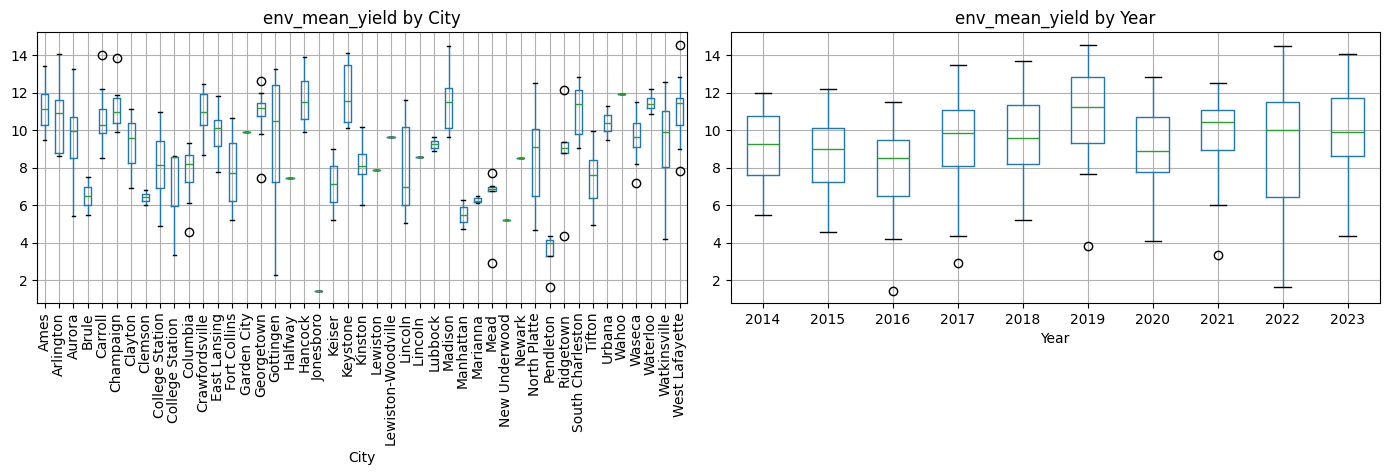

In [30]:
# 3b. env_mean_yield by City/location and by Year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if city_series is not None:
    city_joined = env_targets.join(city_series.rename('city'), how='inner')
    city_order = city_joined.groupby('city')['env_mean_yield'].median().sort_values().index
    city_joined.boxplot(column='env_mean_yield', by='city', ax=axes[0],
                         positions=range(len(city_order)))
    axes[0].set_title('env_mean_yield by City')
    axes[0].set_xlabel('City')
    plt.setp(axes[0].get_xticklabels(), rotation=90)
else:
    axes[0].text(0.5, 0.5, 'No city column matched', ha='center', va='center')

year_series = trait_genotyped.drop_duplicates('Env').set_index('Env')['Year']
year_joined = env_targets.join(year_series.rename('year'), how='inner')
year_joined.boxplot(column='env_mean_yield', by='year', ax=axes[1])
axes[1].set_title('env_mean_yield by Year')
axes[1].set_xlabel('Year')

plt.suptitle('')
plt.tight_layout()
plt.show()

PCA explained variance ratio (PC1, PC2): [0.188 0.169]


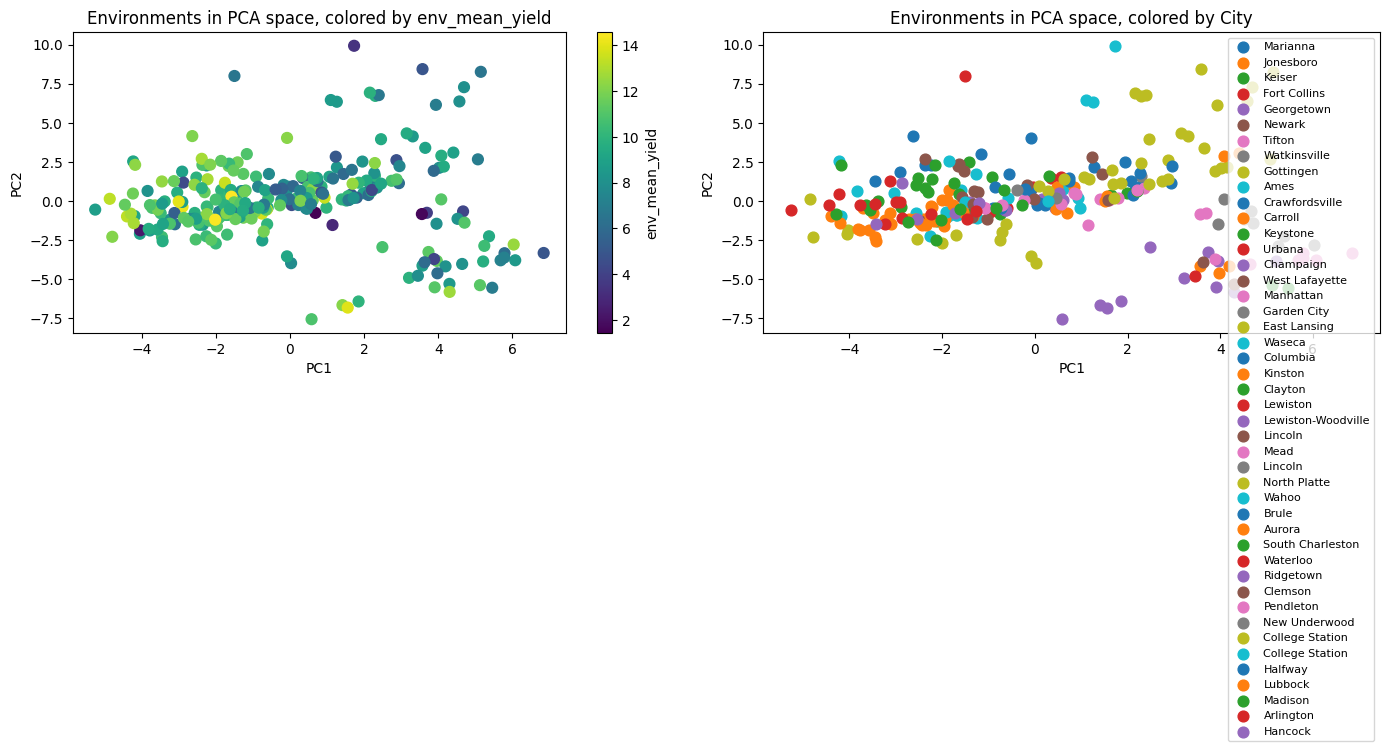

In [31]:
# 3c. Joint clustering: weather + soil + location together, colored by yield and by City
cluster_input = analysis_df[numeric_analysis_cols].copy()
cluster_input = cluster_input.fillna(cluster_input.median())

still_all_nan = cluster_input.columns[cluster_input.isna().all()].tolist()
if still_all_nan:
    raise ValueError(
        f"Column(s) {still_all_nan} are entirely NaN even after median imputation -- "
        "this means every environment is missing this feature. Drop it upstream "
        "(build_soil_features' max_missing_frac) rather than imputing.")

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_input)

pca = PCA(n_components=2, random_state=RNG_SEED)
pca_coords = pca.fit_transform(cluster_scaled)
print(f"PCA explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_.round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc = axes[0].scatter(pca_coords[:, 0], pca_coords[:, 1],
                      c=analysis_df['env_mean_yield'], cmap='viridis', s=60)
axes[0].set_title('Environments in PCA space, colored by env_mean_yield')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc, ax=axes[0], label='env_mean_yield')

if city_series is not None:
    city_aligned = city_series.reindex(analysis_df.index)
    for city in city_aligned.dropna().unique():
        mask = (city_aligned == city).values
        axes[1].scatter(pca_coords[mask, 0], pca_coords[mask, 1], label=city, s=60)
    axes[1].legend(loc='best', fontsize=8)
    axes[1].set_title('Environments in PCA space, colored by City')
else:
    axes[1].text(0.5, 0.5, 'No city column matched', ha='center', va='center')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

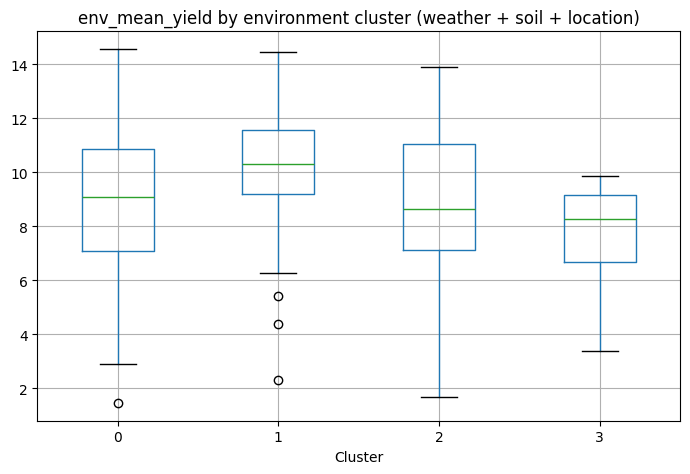

         count       mean       std
cluster                            
0          108   8.928483  2.524810
1          109  10.258836  2.031832
2           36   8.700854  2.841500
3           16   7.768941  1.824586


In [32]:
# 3d. K-means clusters on the same combined feature space, compared against yield
kmeans = KMeans(n_clusters=4, random_state=RNG_SEED, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

cluster_yield_df = analysis_df[['env_mean_yield']].copy()
cluster_yield_df['cluster'] = cluster_labels

fig, ax = plt.subplots(figsize=(7, 5))
cluster_yield_df.boxplot(column='env_mean_yield', by='cluster', ax=ax)
ax.set_title('env_mean_yield by environment cluster (weather + soil + location)')
ax.set_xlabel('Cluster')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(cluster_yield_df.groupby('cluster')['env_mean_yield'].agg(['count', 'mean', 'std']))

In [35]:
# TXH2 weather-gap diagnostic
# Checks whether TXH2_2015/2016/2017 are genuinely absent from the weather
# file, or present under a slightly different Env string (whitespace, case,
# separator differences) that a strict set-difference wouldn't catch.

missing_envs = ['TXH2_2015', 'TXH2_2016', 'TXH2_2017']
weather_envs = weather_season_df['Env'].astype(str)

print("Exact match check:")
for env in missing_envs:
    exact = (weather_envs == env).sum()
    print(f"  {env}: {exact} exact matches in weather file")

print("\nFuzzy check -- any weather Env containing 'TXH2' or the year, case-insensitive:")
fuzzy_mask = weather_envs.str.contains('txh2', case=False, na=False)
fuzzy_matches = sorted(weather_envs[fuzzy_mask].unique())
print(f"  Env values containing 'TXH2' (any case): {fuzzy_matches if fuzzy_matches else 'none found'}")

print("\nWhitespace/formatting check on trait-side Env values for these three:")
trait_envs_raw = trait_genotyped.loc[trait_genotyped['Env'].isin(missing_envs), 'Env']
for env in missing_envs:
    matching_raw = trait_envs_raw[trait_envs_raw == env]
    print(f"  {env!r}: repr in trait file -- {trait_envs_raw.unique().tolist()[:1] if len(matching_raw) else 'n/a'}")

print("\nAll unique weather Env values matching the TX location prefix (any state-code variant):")
tx_prefix_mask = weather_envs.str.startswith('TX', na=False)
print(sorted(weather_envs[tx_prefix_mask].unique()))

Exact match check:
  TXH2_2015: 0 exact matches in weather file
  TXH2_2016: 0 exact matches in weather file
  TXH2_2017: 0 exact matches in weather file

Fuzzy check -- any weather Env containing 'TXH2' or the year, case-insensitive:
  Env values containing 'TXH2' (any case): ['TXH2_2014', 'TXH2_2018', 'TXH2_2019', 'TXH2_2020', 'TXH2_2021', 'TXH2_2022', 'TXH2_2023']

Whitespace/formatting check on trait-side Env values for these three:
  'TXH2_2015': repr in trait file -- ['TXH2_2015']
  'TXH2_2016': repr in trait file -- ['TXH2_2015']
  'TXH2_2017': repr in trait file -- ['TXH2_2015']

All unique weather Env values matching the TX location prefix (any state-code variant):
['TXH1-Dry_2017', 'TXH1-Dry_2018', 'TXH1-Early_2017', 'TXH1-Early_2018', 'TXH1-Late_2017', 'TXH1-Late_2018', 'TXH1_2014', 'TXH1_2015', 'TXH1_2016', 'TXH1_2019', 'TXH1_2020', 'TXH1_2021', 'TXH1_2022', 'TXH1_2023', 'TXH2_2014', 'TXH2_2018', 'TXH2_2019', 'TXH2_2020', 'TXH2_2021', 'TXH2_2022', 'TXH2_2023', 'TXH3_2019', 

In [36]:
# Treatment-suffix naming scan
# Checks whether any Env values contain a hyphenated suffix (e.g. '-Dry',
# '-Early', '-Late') across weather, trait, soil, and meta -- and whether
# the trait file's plain-form environments actually have a weather match
# when a suffixed variant exists instead.

import re

def find_suffixed_envs(series: pd.Series, label: str) -> set[str]:
    envs = series.astype(str).unique()
    suffixed = sorted(e for e in envs if re.search(r'-[A-Za-z]+_\d{4}$', e))
    print(f"{label}: {len(suffixed)} suffixed Env values out of {len(envs)} total")
    if suffixed:
        print(f"  {suffixed}")
    return set(suffixed)


weather_suffixed = find_suffixed_envs(weather_season_df['Env'], 'weather_season_df')
trait_suffixed = find_suffixed_envs(trait_genotyped['Env'], 'trait_genotyped')
soil_suffixed = find_suffixed_envs(soil_df['Env'] if 'Env' in soil_df.columns else soil_df[soil_env_col], 'soil_df')
meta_suffixed = find_suffixed_envs(meta_df[meta_env_col], 'meta_df')

print("\nFor each weather-side suffixed base location+year, does the trait file "
      "have the PLAIN (unsuffixed) form instead?")
for env in weather_suffixed:
    base = re.sub(r'-[A-Za-z]+(_\d{4})$', r'\1', env)
    plain_in_trait = (trait_genotyped['Env'].astype(str) == base).sum()
    suffixed_in_trait = (trait_genotyped['Env'].astype(str) == env).sum()
    print(f"  weather has {env!r} -> trait plain form {base!r}: {plain_in_trait} rows, "
          f"trait suffixed form: {suffixed_in_trait} rows")

weather_season_df: 6 suffixed Env values out of 269 total
  ['TXH1-Dry_2017', 'TXH1-Dry_2018', 'TXH1-Early_2017', 'TXH1-Early_2018', 'TXH1-Late_2017', 'TXH1-Late_2018']
trait_genotyped: 6 suffixed Env values out of 272 total
  ['TXH1-Dry_2017', 'TXH1-Dry_2018', 'TXH1-Early_2017', 'TXH1-Early_2018', 'TXH1-Late_2017', 'TXH1-Late_2018']
soil_df: 0 suffixed Env values out of 186 total
meta_df: 6 suffixed Env values out of 272 total
  ['TXH1-Dry_2017', 'TXH1-Dry_2018', 'TXH1-Early_2017', 'TXH1-Early_2018', 'TXH1-Late_2017', 'TXH1-Late_2018']

For each weather-side suffixed base location+year, does the trait file have the PLAIN (unsuffixed) form instead?
  weather has 'TXH1-Early_2017' -> trait plain form 'TXH1_2017': 0 rows, trait suffixed form: 375 rows
  weather has 'TXH1-Late_2017' -> trait plain form 'TXH1_2017': 0 rows, trait suffixed form: 278 rows
  weather has 'TXH1-Late_2018' -> trait plain form 'TXH1_2018': 0 rows, trait suffixed form: 498 rows
  weather has 'TXH1-Dry_2017' -> tra

In [37]:
# Explicit exclusion list for environments with no weather record --
# the environment-alone model cannot produce features for these, so they
# should be dropped from that model's training/eval rather than silently
# carrying a missing feature row forward.
ENVS_WITHOUT_WEATHER = ['TXH2_2015', 'TXH2_2016', 'TXH2_2017']

print(f"Environments excluded from environment-alone modeling (no weather record): "
      f"{ENVS_WITHOUT_WEATHER}")
print(f"Trait rows affected: "
      f"{trait_genotyped['Env'].isin(ENVS_WITHOUT_WEATHER).sum()} "
      f"({trait_genotyped['Env'].isin(ENVS_WITHOUT_WEATHER).mean():.2%} of trait_genotyped)")

env_targets_modelable = env_targets.drop(index=ENVS_WITHOUT_WEATHER, errors='ignore')
print(f"env_targets: {len(env_targets)} -> {len(env_targets_modelable)} after exclusion")

Environments excluded from environment-alone modeling (no weather record): ['TXH2_2015', 'TXH2_2016', 'TXH2_2017']
Trait rows affected: 1223 (0.75% of trait_genotyped)
env_targets: 272 -> 269 after exclusion


### Interpreting this before finalizing the feature vector

- **Correlation table**: any feature with a small |correlation| against
  `env_mean_yield` is a weak individual candidate -- doesn't mean drop it
  outright (interactions can matter even when marginal correlation is low),
  but it's a data point.
- **City/Year boxplots**: wide separation between City groups means location
  carries signal weather alone doesn't fully explain (soil type, regional
  practice, unmeasured local effects) -- a reason to keep lat/long. Wide
  separation by Year (independent of weather, since weather should already
  capture year-to-year climate variation) would point to something
  structural changing over time (genetics improving, management practices)
  worth flagging as a modeling risk instead of an environment feature.
- **PCA colored by yield vs. by City**: if the two colorings produce
  visually similar groupings, City and the weather/soil features are
  capturing overlapping information -- less reason to include both. If they
  diverge, each is adding independent signal.
- **K-means cluster boxplot**: if clusters show clearly different yield
  distributions, the combined feature space is doing meaningful work
  separating high- and low-yield environments -- supports including soil
  and location, not just weather, in the final vector.

Paste back the printed correlation table and the four plots -- that decides
which features make it into the final `environment_features.csv` written in
Section 4 below.

## Section 4 -- Alignment checks
Confirms coverage before saving: every hybrid used in Section 1 has a
genotype row (should be ~100% by construction), and every environment used
in Section 2 has engineered weather features.

In [33]:
hybrids_missing_geno = set(hybrid_targets.index) - genotyped_hybrids
print(f"Hybrids in targets without genotype coverage: {len(hybrids_missing_geno)} "
      f"(expected 0 -- targets were built from the genotype-filtered trait data)")

envs_missing_weather = set(env_targets.index) - set(env_weather_features.index)
print(f"Environments in targets without weather features: {len(envs_missing_weather)}")
if envs_missing_weather:
    print(f"  {sorted(envs_missing_weather)}")

envs_missing_target = set(env_weather_features.index) - set(env_targets.index)
print(f"Environments with weather features but no target "
      f"(no genotyped-hybrid trait records -- these can't be used for training): "
      f"{len(envs_missing_target)}")
if envs_missing_target:
    print(f"  {sorted(envs_missing_target)}")

Hybrids in targets without genotype coverage: 0 (expected 0 -- targets were built from the genotype-filtered trait data)
Environments in targets without weather features: 3
  ['TXH2_2015', 'TXH2_2016', 'TXH2_2017']
Environments with weather features but no target (no genotyped-hybrid trait records -- these can't be used for training): 0


## Section 5 -- Save representations
Writes both representations to `data/processed/` so `03_genotype_model.ipynb`
and `04_environment_model.ipynb` load prebuilt features directly.

**Note:** `env_combined_features` (weather + soil + location, as explored in
Section 3) is saved alongside the weather-only version so the feature
decision can still be made explicitly in the model notebook, based on what
Section 3's plots show, rather than locked in here.

In [34]:
hybrid_targets.to_csv(DATA_PROCESSED / 'genotype_hybrid_targets.csv')
env_targets.to_csv(DATA_PROCESSED / 'environment_targets.csv')
env_weather_features.to_csv(DATA_PROCESSED / 'environment_weather_features.csv')
env_combined_features.to_csv(DATA_PROCESSED / 'environment_combined_features.csv')

# Genotype dosage matrix, filtered to hybrids that have a target -- saved
# separately since it's the model input, not a target/metadata table
geno_num.loc[geno_num.index.isin(hybrid_targets.index)].to_csv(
    DATA_PROCESSED / 'genotype_dosage_matrix_filtered.csv')

print("Saved:")
for f in ['genotype_hybrid_targets.csv', 'environment_targets.csv',
          'environment_weather_features.csv', 'environment_combined_features.csv',
          'genotype_dosage_matrix_filtered.csv']:
    p = DATA_PROCESSED / f
    print(f"  {p} ({p.stat().st_size / 1024:.1f} KB)")

Saved:
  /content/drive/MyDrive/g2f_effect_decomposition/data/processed/genotype_hybrid_targets.csv (288.5 KB)
  /content/drive/MyDrive/g2f_effect_decomposition/data/processed/environment_targets.csv (14.7 KB)
  /content/drive/MyDrive/g2f_effect_decomposition/data/processed/environment_weather_features.csv (42.4 KB)
  /content/drive/MyDrive/g2f_effect_decomposition/data/processed/environment_combined_features.csv (79.7 KB)
  /content/drive/MyDrive/g2f_effect_decomposition/data/processed/genotype_dosage_matrix_filtered.csv (45738.0 KB)


## Summary

- `genotype_hybrid_targets.csv`: per-hybrid marginal mean yield + reliability
  (n environments tested) -- exploratory target for the genotype-alone model
- `environment_targets.csv`: per-environment marginal mean yield +
  reliability (n hybrids tested) -- exploratory target for the
  environment-alone model
- `environment_weather_features.csv`: engineered, fixed-length weather
  feature vector per environment (Option B representation)
- `environment_combined_features.csv`: weather + imputed soil (with a
  `has_soil_data` flag) + latitude/longitude, for use if Section 3's
  exploration supports including soil/location
- `genotype_dosage_matrix_filtered.csv`: raw dosage matrix, filtered to
  hybrids with a target

**Reminder for the model notebooks:** the targets and imputation statistics
saved here are computed from the full training set and are for
exploration/sanity-checking only. Both `03_genotype_model.ipynb` and
`04_environment_model.ipynb` must recompute per-hybrid / per-environment
means and refit any imputation medians inside each CV fold using only that
fold's training-year data, or held-out-year information leaks into the
"fixed" effect value being predicted.